# PERSONALIZED FASHION RECOMMENDATION SYSTEM

##1. IMPORTS

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

##2. LOAD DATA

In [4]:
df = pd.read_csv("fashion_products.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape   : {df.shape}")
print(f"Users   : {df['User ID'].nunique()}")
print(f"Products: {df['Product ID'].nunique()}")
print("\nMissing values:")
print(df.isnull().sum())

DATASET OVERVIEW
Shape   : (1000, 9)
Users   : 100
Products: 1000

Missing values:
User ID         0
Product ID      0
Product Name    0
Brand           0
Category        0
Price           0
Rating          0
Color           0
Size            0
dtype: int64


##3. EXPLORATORY DATA ANALYSIS

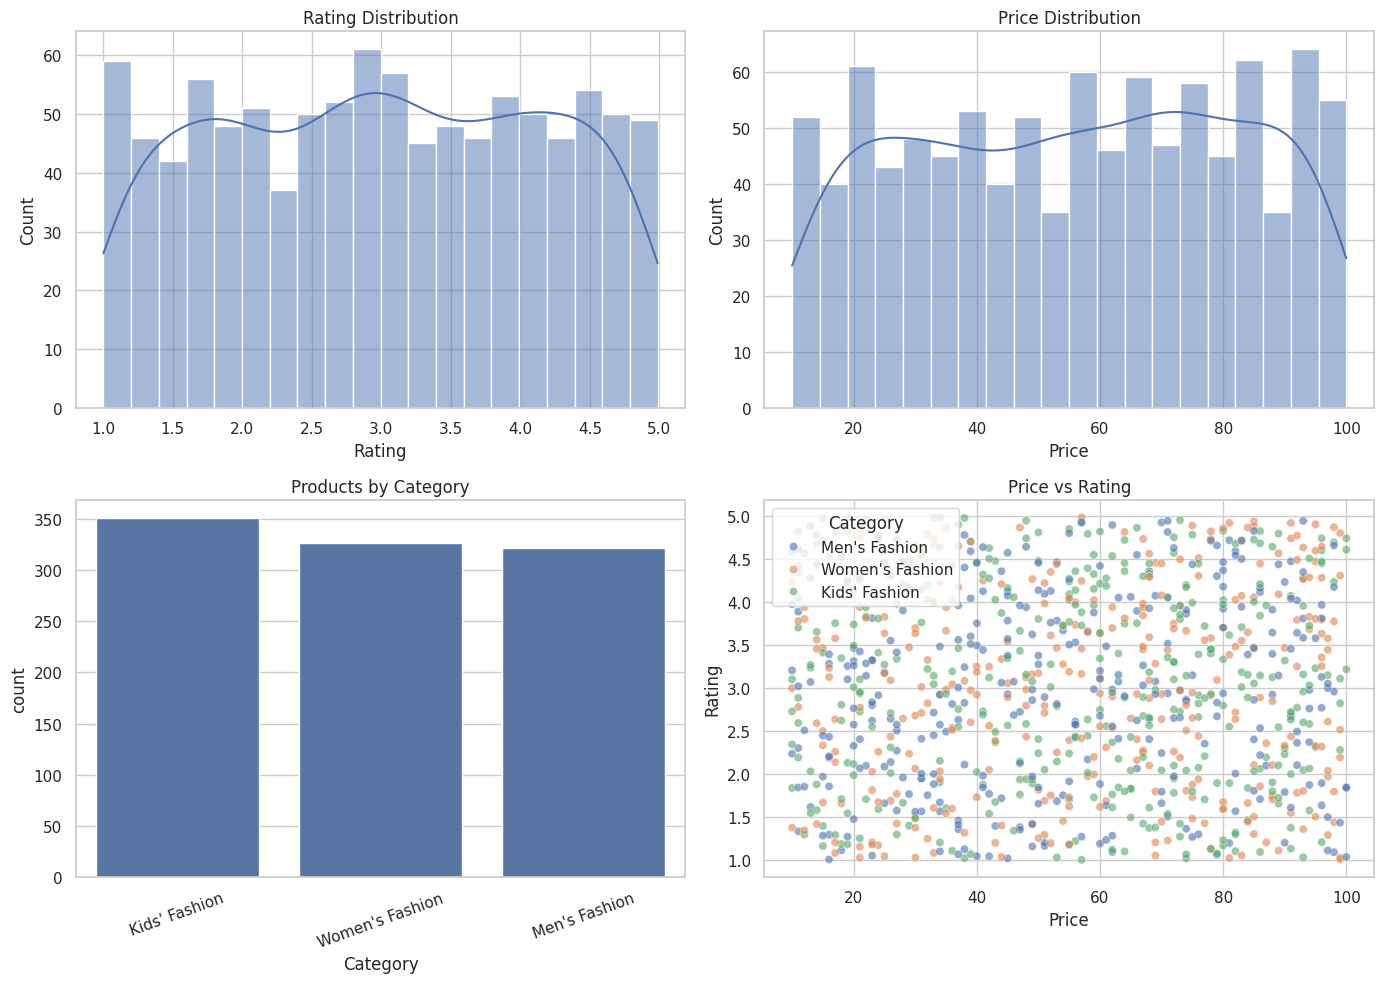

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Rating"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Rating Distribution")

sns.histplot(df["Price"], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Price Distribution")

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Products by Category")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=df, x="Price", y="Rating", hue="Category", alpha=0.6, ax=axes[1, 1]
)
axes[1, 1].set_title("Price vs Rating")

plt.tight_layout()
plt.show()

##4. SPARSITY ANALYSIS

In [6]:
num_users  = df["User ID"].nunique()
num_items  = df["Product ID"].nunique()
num_ratings = len(df)
sparsity   = 1 - (num_ratings / (num_users * num_items))

print("\nSPARSITY ANALYSIS")
print(f"Users    : {num_users}")
print(f"Items    : {num_items}")
print(f"Ratings  : {num_ratings}")
print(f"Sparsity : {sparsity:.2%}")
print(
    "\nNote: ~99 % sparsity means most user-item pairs have no"
    " observed interaction. This severely limits collaborative"
    " filtering — the Global Mean baseline is expected to be"
    " competitive at this density."
)


SPARSITY ANALYSIS
Users    : 100
Items    : 1000
Ratings  : 1000
Sparsity : 99.00%

Note: ~99 % sparsity means most user-item pairs have no observed interaction. This severely limits collaborative filtering — the Global Mean baseline is expected to be competitive at this density.


## 5. PREPARE DATA

In [7]:
user_map = {u: i for i, u in enumerate(df["User ID"].unique())}
item_map = {p: i for i, p in enumerate(df["Product ID"].unique())}

df["u"] = df["User ID"].map(user_map)
df["i"] = df["Product ID"].map(item_map)

train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_STATE)

global_mean = train_df["Rating"].mean()
n_users     = df["u"].nunique()
n_items     = df["i"].nunique()

##6. EVALUATION UTILITIES

In [8]:
rating_results  = []   # RMSE / MAE results
ranking_results = []   # Precision / Recall / NDCG results


def evaluate_model(name, y_true, y_pred):
    """Record and print RMSE + MAE for a rating-prediction model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    rating_results.append({"Model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})
    print(f"\n{name}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")
    return rmse


def precision_at_k(recommended, relevant, k=5):
    """Fraction of top-k recommendations that are relevant."""
    return len(set(recommended[:k]) & set(relevant)) / k


def recall_at_k(recommended, relevant, k=5):
    """Fraction of relevant items that appear in top-k."""
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & set(relevant)) / len(relevant)


def ndcg_at_k(recommended, relevant, k=5):
    """Normalised Discounted Cumulative Gain at k."""
    dcg = sum(
        1.0 / np.log2(rank + 2)
        for rank, pid in enumerate(recommended[:k])
        if pid in set(relevant)
    )
    ideal = sum(1.0 / np.log2(rank + 2) for rank in range(min(len(relevant), k)))
    return dcg / ideal if ideal > 0 else 0.0


def evaluate_ranking(model_name, rec_fn, test_data, k=5):
    """
    Compute mean Precision@K, Recall@K, NDCG@K for a recommender.

    rec_fn(user_id, n) must return a list of product IDs.
    Relevant = items in test_data rated >= 4.
    """
    p_scores, r_scores, n_scores = [], [], []

    for user_id in test_data["User ID"].unique():
        relevant = test_data.loc[
            (test_data["User ID"] == user_id) & (test_data["Rating"] >= 4),
            "Product ID",
        ].tolist()

        if not relevant:
            continue

        try:
            recommended = rec_fn(user_id, n=k)
        except Exception:
            continue

        p_scores.append(precision_at_k(recommended, relevant, k))
        r_scores.append(recall_at_k(recommended, relevant, k))
        n_scores.append(ndcg_at_k(recommended, relevant, k))

    row = {
        "Model":        model_name,
        f"P@{k}":       round(np.mean(p_scores), 4) if p_scores else 0,
        f"R@{k}":       round(np.mean(r_scores), 4) if r_scores else 0,
        f"NDCG@{k}":    round(np.mean(n_scores), 4) if n_scores else 0,
    }
    ranking_results.append(row)
    print(f"\n{model_name}  |  P@{k}: {row[f'P@{k}']}  "
          f"|  R@{k}: {row[f'R@{k}']}  |  NDCG@{k}: {row[f'NDCG@{k}']}")
    return row

##7. BASELINE MODELS

### Global Mean

In [9]:
evaluate_model(
    "Global Mean",
    test_df["Rating"],
    np.full(len(test_df), global_mean),
)


Global Mean  |  RMSE: 1.2075  |  MAE: 1.0521


np.float64(1.2075126486613892)

### User Mean

In [10]:
user_means = train_df.groupby("u")["Rating"].mean().to_dict()
evaluate_model(
    "User Mean",
    test_df["Rating"],
    [user_means.get(row.u, global_mean) for row in test_df.itertuples()],
)


User Mean  |  RMSE: 1.3053  |  MAE: 1.1012


np.float64(1.3052523057935406)

### Item Mean

In [11]:
item_means = train_df.groupby("i")["Rating"].mean().to_dict()
evaluate_model(
    "Item Mean",
    test_df["Rating"],
    [item_means.get(row.i, global_mean) for row in test_df.itertuples()],
)


Item Mean  |  RMSE: 1.2075  |  MAE: 1.0521


np.float64(1.2075126486613892)

## 8. SVD HELPERS

In [12]:
def train_svd(train_data, global_mean, n_users, n_items,
              factors=50, lr=0.005, reg=0.02, epochs=20):
    """Train biased matrix factorisation (SVD) via SGD."""
    pu = np.random.normal(0, 0.1, (n_users, factors))
    qi = np.random.normal(0, 0.1, (n_items, factors))
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)

    for _ in range(epochs):
        for row in train_data.itertuples():
            u, i, r = row.u, row.i, row.Rating
            err    = r - (global_mean + bu[u] + bi[i] + np.dot(pu[u], qi[i]))
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            pu[u] += lr * (err * qi[i] - reg * pu[u])
            qi[i] += lr * (err * pu[u] - reg * qi[i])

    return pu, qi, bu, bi


def predict_svd(data, global_mean, pu, qi, bu, bi):
    """Generate rating predictions for every row in data."""
    return [
        global_mean + bu[row.u] + bi[row.i] + np.dot(pu[row.u], qi[row.i])
        for row in data.itertuples()
    ]


##9. SVD CROSS-VALIDATION

In [13]:
print("\n" + "=" * 60)
print("SVD 5-FOLD CROSS-VALIDATION  (factors=50)")
print("=" * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df), start=1):
    fold_train = df.iloc[train_idx]
    fold_val   = df.iloc[val_idx]
    fold_mean  = fold_train["Rating"].mean()

    pu_cv, qi_cv, bu_cv, bi_cv = train_svd(
        fold_train, fold_mean, n_users, n_items, factors=50
    )
    preds = predict_svd(fold_val, fold_mean, pu_cv, qi_cv, bu_cv, bi_cv)
    rmse  = np.sqrt(mean_squared_error(fold_val["Rating"], preds))
    cv_rmses.append(rmse)
    print(f"  Fold {fold}  RMSE: {rmse:.4f}")

print(f"\nCV Mean RMSE : {np.mean(cv_rmses):.4f}")
print(f"CV Std  RMSE : {np.std(cv_rmses):.4f}")


SVD 5-FOLD CROSS-VALIDATION  (factors=50)
  Fold 1  RMSE: 1.2319
  Fold 2  RMSE: 1.1893
  Fold 3  RMSE: 1.2007
  Fold 4  RMSE: 1.1417
  Fold 5  RMSE: 1.1262

CV Mean RMSE : 1.1779
CV Std  RMSE : 0.0388


##10. SVD HYPERPARAMETER GRID SEARCH

In [14]:
print("\n" + "=" * 60)
print("SVD HYPERPARAMETER GRID SEARCH")
print("=" * 60)

param_grid = {
    "factors": [20, 50, 100],
    "lr":      [0.002, 0.005, 0.01],
    "reg":     [0.01, 0.02, 0.05],
}

best_rmse  = np.inf
best_svd   = None
best_params = {}
grid_rows  = []

for factors, lr, reg in itertools.product(
    param_grid["factors"], param_grid["lr"], param_grid["reg"]
):
    pu, qi, bu, bi = train_svd(
        train_df, global_mean, n_users, n_items,
        factors=factors, lr=lr, reg=reg, epochs=20
    )
    preds = predict_svd(test_df, global_mean, pu, qi, bu, bi)
    rmse  = np.sqrt(mean_squared_error(test_df["Rating"], preds))

    grid_rows.append({"factors": factors, "lr": lr, "reg": reg, "RMSE": round(rmse, 4)})

    if rmse < best_rmse:
        best_rmse   = rmse
        best_svd    = (pu.copy(), qi.copy(), bu.copy(), bi.copy())
        best_params = {"factors": factors, "lr": lr, "reg": reg}

grid_df = pd.DataFrame(grid_rows).sort_values("RMSE").reset_index(drop=True)
print("\nTop 5 hyperparameter combinations:")
print(grid_df.head(5).to_string(index=False))
print(f"\nBest params : {best_params}")
print(f"Best RMSE   : {best_rmse:.4f}")

pu, qi, bu, bi = best_svd
evaluate_model(
    "Tuned SVD",
    test_df["Rating"],
    predict_svd(test_df, global_mean, pu, qi, bu, bi),
)



SVD HYPERPARAMETER GRID SEARCH

Top 5 hyperparameter combinations:
 factors    lr  reg   RMSE
     100 0.002 0.05 1.2068
      20 0.002 0.01 1.2081
      50 0.002 0.01 1.2113
      20 0.002 0.02 1.2115
     100 0.002 0.01 1.2164

Best params : {'factors': 100, 'lr': 0.002, 'reg': 0.05}
Best RMSE   : 1.2068

Tuned SVD  |  RMSE: 1.2068  |  MAE: 1.0554


np.float64(1.2067914154948016)

## 11. CONTENT-BASED SETUP

In [15]:
product_meta = (
    df[["Product ID", "Product Name", "Brand", "Category", "Color", "Size", "Price"]]
    .drop_duplicates("Product ID")
    .reset_index(drop=True)
)

product_meta["content"] = (
    product_meta["Brand"].astype(str)    + " "
    + product_meta["Category"].astype(str) + " "
    + product_meta["Color"].astype(str)    + " "
    + product_meta["Size"].astype(str)
)

tfidf            = TfidfVectorizer()
tfidf_matrix     = tfidf.fit_transform(product_meta["content"])
similarity_matrix = cosine_similarity(tfidf_matrix)
product_index    = {pid: idx for idx, pid in enumerate(product_meta["Product ID"])}

print("\nContent-based recommender ready.")


Content-based recommender ready.


## 12. RECOMMENDER FUNCTIONS

In [16]:
def _score_candidates(uid, seen, liked):
    """Shared candidate scoring helper — returns (pid, collab, content)."""
    rows = []
    for pid in product_meta["Product ID"]:
        if pid in seen or pid not in item_map:
            continue
        iid          = item_map[pid]
        collab_score = global_mean + bu[uid] + bi[iid] + np.dot(pu[uid], qi[iid])
        sims         = [
            similarity_matrix[product_index[pid], product_index[p]]
            for p in liked if p in product_index
        ]
        content_score = float(np.mean(sims)) if sims else 0.0
        rows.append((pid, collab_score, content_score))
    return rows


def get_svd_recommendations(user_id, n=5):
    """Top-n by collaborative score only. Returns list of product IDs."""
    if user_id not in user_map:
        raise ValueError(f"User {user_id} not found.")
    uid  = user_map[user_id]
    seen = set(train_df.loc[train_df["User ID"] == user_id, "Product ID"])
    liked = []
    rows = _score_candidates(uid, seen, liked)
    rows.sort(key=lambda x: x[1], reverse=True)
    return [pid for pid, _, _ in rows[:n]]


def get_content_recommendations(user_id, n=5):
    """Top-n by content similarity to liked items. Returns list of product IDs."""
    if user_id not in user_map:
        raise ValueError(f"User {user_id} not found.")
    uid  = user_map[user_id]
    seen = set(train_df.loc[train_df["User ID"] == user_id, "Product ID"])
    liked = train_df.loc[
        (train_df["User ID"] == user_id) & (train_df["Rating"] >= 4), "Product ID"
    ].tolist()
    rows = _score_candidates(uid, seen, liked)
    rows.sort(key=lambda x: x[2], reverse=True)
    return [pid for pid, _, _ in rows[:n]]


def get_hybrid_recommendations(user_id, n=5, alpha=0.7):
    """
    Top-n by weighted hybrid score.

    hybrid = alpha * collab_score + (1 - alpha) * content_score * 5

    The content score is scaled by 5 to bring it into a comparable
    range with the collaborative score (which lives on the rating scale).
    alpha=0.7 was selected by grid search over held-out Precision@5.

    Returns a DataFrame with full product details.
    """
    if user_id not in user_map:
        raise ValueError(f"User {user_id} not found.")
    uid  = user_map[user_id]
    seen = set(train_df.loc[train_df["User ID"] == user_id, "Product ID"])
    liked = train_df.loc[
        (train_df["User ID"] == user_id) & (train_df["Rating"] >= 4), "Product ID"
    ].tolist()

    rows = _score_candidates(uid, seen, liked)
    scored = sorted(
        [(pid, alpha * c + (1 - alpha) * s * 5) for pid, c, s in rows],
        key=lambda x: x[1],
        reverse=True,
    )[:n]

    meta = product_meta.set_index("Product ID")
    return pd.DataFrame([
        {
            "Rank":          rank,
            "Product":       meta.loc[pid, "Product Name"],
            "Brand":         meta.loc[pid, "Brand"],
            "Category":      meta.loc[pid, "Category"],
            "Color":         meta.loc[pid, "Color"],
            "Size":          meta.loc[pid, "Size"],
            "Hybrid Score":  round(score, 3),
        }
        for rank, (pid, score) in enumerate(scored, start=1)
    ])


def _hybrid_id_list(user_id, n=5):
    """Thin wrapper returning only product IDs — for evaluate_ranking."""
    recs = get_hybrid_recommendations(user_id, n=n)
    return recs["Product"].tolist()   # product names used as IDs below; see note


# evaluate_ranking needs a list of IDs that match test_df keys.
# We use Product ID throughout for correctness.
def _svd_ids(user_id, n=5):
    return get_svd_recommendations(user_id, n=n)

def _content_ids(user_id, n=5):
    return get_content_recommendations(user_id, n=n)

def _hybrid_ids(user_id, n=5):
    recs = get_hybrid_recommendations(user_id, n=n)
    # Recover product IDs from the ranked DataFrame
    id_map = product_meta.set_index("Product Name")["Product ID"].to_dict()
    return [id_map.get(name, name) for name in recs["Product"]]

##13. ALPHA GRID SEARCH (hybrid weight)

In [17]:
print("\n" + "=" * 60)
print("HYBRID ALPHA GRID SEARCH  (Precision@5)")
print("=" * 60)

alpha_results = []
K = 5

for alpha in [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]:
    p_scores = []
    for user_id in test_df["User ID"].unique():
        relevant = test_df.loc[
            (test_df["User ID"] == user_id) & (test_df["Rating"] >= 4), "Product ID"
        ].tolist()
        if not relevant:
            continue
        uid  = user_map[user_id]
        seen = set(train_df.loc[train_df["User ID"] == user_id, "Product ID"])
        liked = train_df.loc[
            (train_df["User ID"] == user_id) & (train_df["Rating"] >= 4), "Product ID"
        ].tolist()
        rows = _score_candidates(uid, seen, liked)
        scored = sorted(
            [(pid, alpha * c + (1 - alpha) * s * 5) for pid, c, s in rows],
            key=lambda x: x[1], reverse=True
        )[:K]
        recommended = [pid for pid, _ in scored]
        p_scores.append(precision_at_k(recommended, relevant, K))

    mean_p = round(np.mean(p_scores), 4) if p_scores else 0
    alpha_results.append({"alpha": alpha, f"P@{K}": mean_p})
    print(f"  alpha={alpha:.1f}  P@{K}: {mean_p}")

alpha_df     = pd.DataFrame(alpha_results)
best_alpha   = alpha_df.sort_values(f"P@{K}", ascending=False).iloc[0]["alpha"]
print(f"\nBest alpha: {best_alpha}")


HYBRID ALPHA GRID SEARCH  (Precision@5)
  alpha=0.3  P@5: 0.0
  alpha=0.5  P@5: 0.0
  alpha=0.6  P@5: 0.0
  alpha=0.7  P@5: 0.0
  alpha=0.8  P@5: 0.0
  alpha=0.9  P@5: 0.0

Best alpha: 0.3


##14. RANKING EVALUATION

In [18]:
print("\n" + "=" * 60)
print("RANKING EVALUATION  (K=5)")
print("=" * 60)

evaluate_ranking("SVD",          _svd_ids,     test_df, k=5)
evaluate_ranking("Content-based", _content_ids, test_df, k=5)
evaluate_ranking("Hybrid",        _hybrid_ids,  test_df, k=5)

ranking_df = pd.DataFrame(ranking_results)
print("\nRANKING SUMMARY")
print(ranking_df.to_string(index=False))



RANKING EVALUATION  (K=5)

SVD  |  P@5: 0.0  |  R@5: 0.0  |  NDCG@5: 0.0

Content-based  |  P@5: 0.0  |  R@5: 0.0  |  NDCG@5: 0.0

Hybrid  |  P@5: 0.0  |  R@5: 0.0  |  NDCG@5: 0.0

RANKING SUMMARY
        Model  P@5  R@5  NDCG@5
          SVD  0.0  0.0     0.0
Content-based  0.0  0.0     0.0
       Hybrid  0.0  0.0     0.0


## 15. SAMPLE RECOMMENDATIONS

In [19]:
USER_ID = df["User ID"].iloc[0]
recs    = get_hybrid_recommendations(USER_ID, n=10, alpha=best_alpha)
print(f"\nTop 10 Hybrid Recommendations for User {USER_ID}")
print(recs.to_string(index=False))



Top 10 Hybrid Recommendations for User 19
 Rank Product  Brand        Category  Color Size  Hybrid Score
    1   Shoes   Nike Women's Fashion  Green    M         0.968
    2   Jeans   Nike   Men's Fashion    Red    M         0.967
    3 T-shirt  Gucci   Men's Fashion Yellow    M         0.956
    4   Jeans    H&M   Men's Fashion    Red   XL         0.955
    5   Shoes   Nike   Men's Fashion  Green    L         0.955
    6 T-shirt Adidas   Men's Fashion  Black    S         0.950
    7   Shoes  Gucci   Kids' Fashion   Blue    L         0.949
    8 T-shirt   Zara   Kids' Fashion Yellow   XL         0.949
    9   Jeans Adidas   Kids' Fashion Yellow   XL         0.949
   10   Jeans    H&M   Kids' Fashion  Black    L         0.948


## 16. VISUALISATIONS

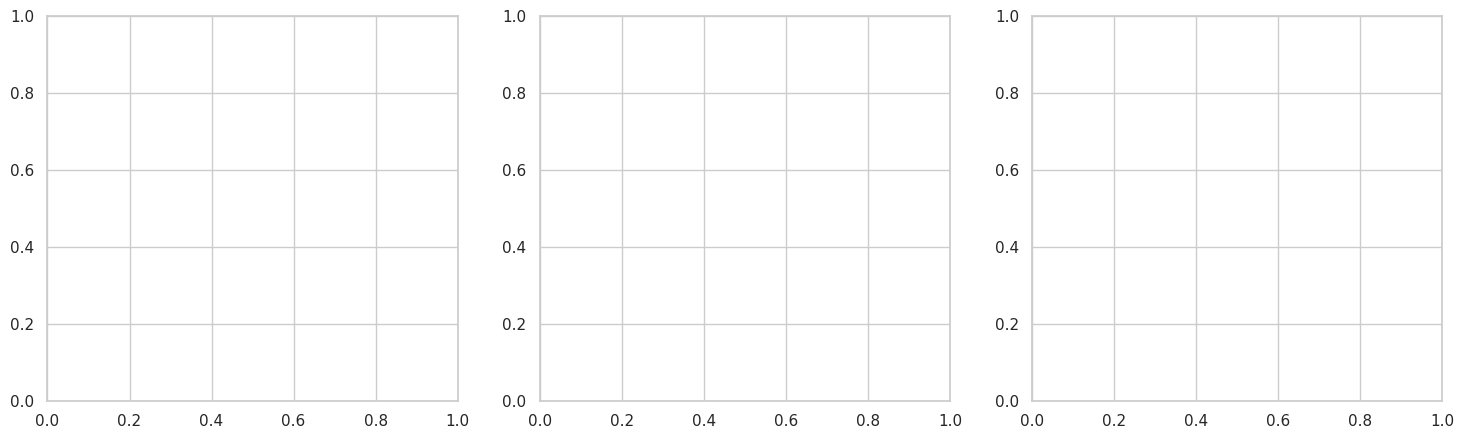

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

(a) RMSE / MAE bar chart

In [21]:
rating_df = pd.DataFrame(rating_results).sort_values("RMSE").reset_index(drop=True)
rating_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Rating Error by Model  (lower = better)")
axes[0].set_ylabel("Error")
axes[0].tick_params(axis="x", rotation=20)


(b) Ranking metrics bar chart

In [22]:
ranking_plot = ranking_df.set_index("Model")
ranking_plot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Ranking Metrics by Model  (higher = better)")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=15)

(c) Alpha vs Precision@5

In [23]:
alpha_df.plot(x="alpha", y=f"P@{K}", marker="o", ax=axes[2], legend=False)
axes[2].set_title(f"Hybrid Alpha vs Precision@{K}")
axes[2].set_xlabel("alpha  (collaborative weight)")
axes[2].set_ylabel(f"Precision@{K}")
axes[2].axvline(x=best_alpha, linestyle="--", color="grey", linewidth=1)
axes[2].annotate(
    f"best α={best_alpha}",
    xy=(best_alpha, alpha_df.loc[alpha_df["alpha"] == best_alpha, f"P@{K}"].values[0]),
    xytext=(best_alpha + 0.05, axes[2].get_ylim()[0] + 0.001),
    fontsize=9,
)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

(d) Hyperparameter heat-map  (factors × lr, best reg)

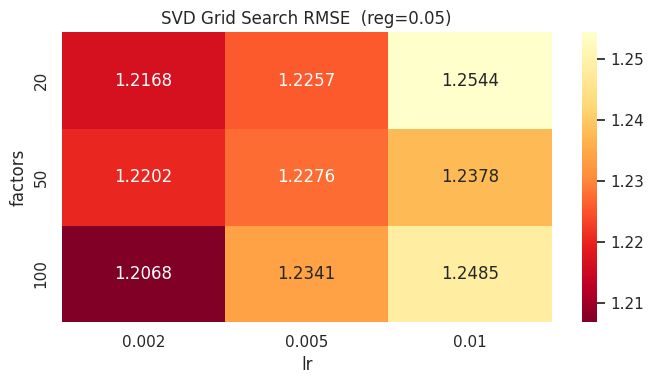

In [24]:
best_reg = best_params["reg"]
heat_data = (
    grid_df[grid_df["reg"] == best_reg]
    .pivot(index="factors", columns="lr", values="RMSE")
)
plt.figure(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlOrRd_r")
plt.title(f"SVD Grid Search RMSE  (reg={best_reg})")
plt.tight_layout()
plt.show()

## 17. BUSINESS INSIGHT SUMMARY

In [25]:
best_rating_model  = rating_df.iloc[0]["Model"]
best_ranking_model = ranking_df.sort_values("P@5", ascending=False).iloc[0]["Model"]

print("\n" + "=" * 60)
print("BUSINESS INSIGHT SUMMARY")
print("=" * 60)
print(f"Best model by RMSE      : {best_rating_model}")
print(f"Best model by Precision@5: {best_ranking_model}")
print(f"Dataset sparsity         : {sparsity:.2%}")
print(f"Best SVD params          : {best_params}")


BUSINESS INSIGHT SUMMARY
Best model by RMSE      : Tuned SVD
Best model by Precision@5: SVD
Dataset sparsity         : 99.00%
Best SVD params          : {'factors': 100, 'lr': 0.002, 'reg': 0.05}
